# Step 5 - Mock inversion testset

Build the observations to invert: crop a prepared synthetic Stokes cube
(`/dat/milic/adora_synth/test.npz.npy`, 1536x1536x4x201) to the first 384x384 px, every 3rd ->
**128x128 px at 48 km spacing**. It was made with the same Adora RT as the forward model, so its Stokes
units match the PINN's. We visualise the observations and frame the inversion by overlaying the
**initial model** (the pretrained FAL-C field, B=0) against them.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('.')); sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../3dtesting'))
import gpu; dev = gpu.use_gpu()             # idlest GPU, no pre-alloc (BEFORE importing jax)
%matplotlib inline
import time, numpy as np, matplotlib.pyplot as plt
import make_inversion_testset as mk, atmosphere_field as af, rt_forward as rf
import jax; print('CUDA_VISIBLE_DEVICES =', dev, '| jax backend:', jax.default_backend())

CUDA_VISIBLE_DEVICES = 3 | jax backend: gpu


In [2]:
out, obs, waves = mk.build()               # create + save the testset
print('testset', obs.shape, '->', out)

testset (128, 128, 4, 201) -> /dat/milic/adora_pinn_develop/inversion_testset.npz


### The observations
Continuum granulation and the Stokes V polarity map (real magnetic structure from the MURaM cube),
and the full I,Q,U,V profiles at the most strongly polarised pixel.

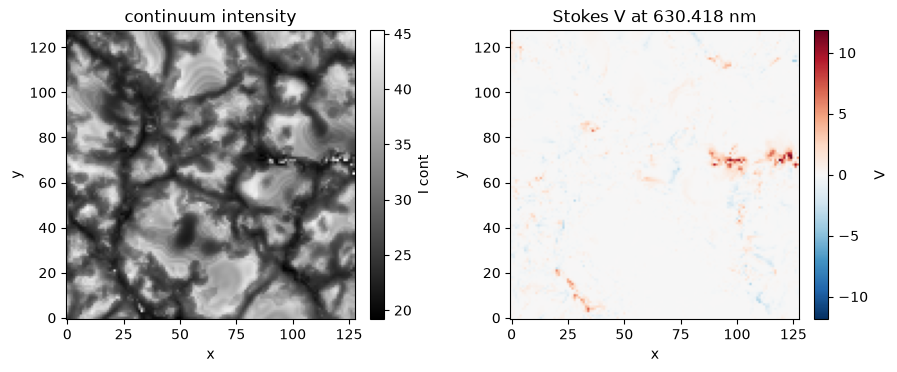

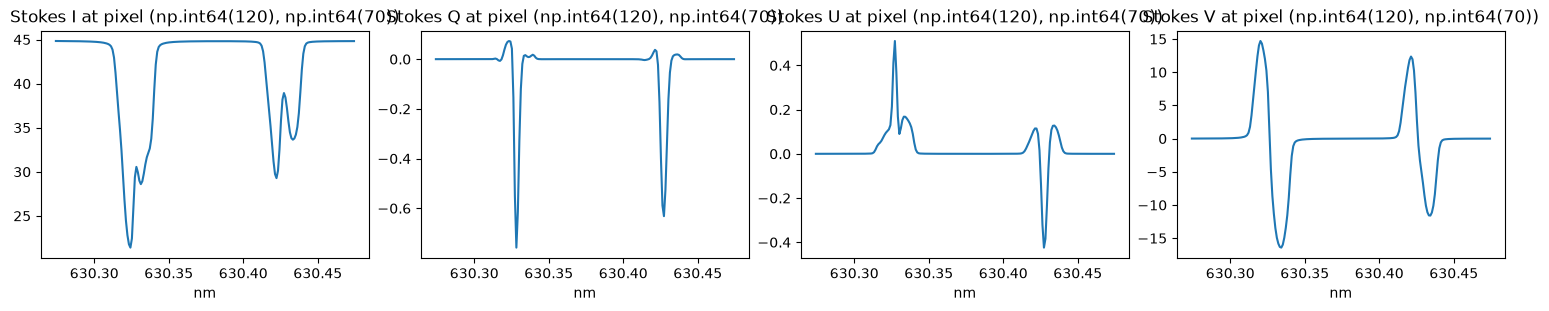

In [6]:
Ic = obs[..., 0, 0]
iV = np.unravel_index(np.argmax(np.abs(obs[:,:,3,:]).max(-1)), Ic.shape)   # strongest |V| pixel
kw = int(np.argmax(np.abs(obs[:,:,3,:]).mean((0,1))))                       # a V-rich wavelength
fig, ax = plt.subplots(1, 2, figsize=(9, 3.6), layout='constrained')
im0 = ax[0].imshow(Ic.T, origin='lower', cmap='gray'); plt.colorbar(im0, ax=ax[0], label='I cont')
ax[0].set(title='continuum intensity', xlabel='x', ylabel='y')
m = np.abs(obs[:,:,3,kw]).max()
im1 = ax[1].imshow(obs[:,:,3,kw].T, origin='lower', cmap='RdBu_r', vmin=-m, vmax=m)
plt.colorbar(im1, ax=ax[1], label='V'); ax[1].set(title=f'Stokes V at {waves[kw]:.3f} nm', xlabel='x', ylabel='y')
plt.show()
fig, ax = plt.subplots(1, 4, figsize=(15, 3), layout='constrained')
for a, k, s in zip(ax, range(4), 'IQUV'):
    a.plot(waves, obs[iV[0], iV[1], k]); a.set(title=f'Stokes {s} at pixel {iV}', xlabel='nm')
plt.show()

### Initial model vs observations (the inversion starting point)
Synth the pretrained FAL-C field over the same grid and compare. The initial model is non-magnetic
(V=0) and horizontally uniform, so I differs and V is entirely missing - exactly what the inversion
must reduce.

synth: 100%|██████████| 4/4 [00:03<00:00,  1.26chunk/s]


initial-model synth (128, 128, 4, 201) in 5s


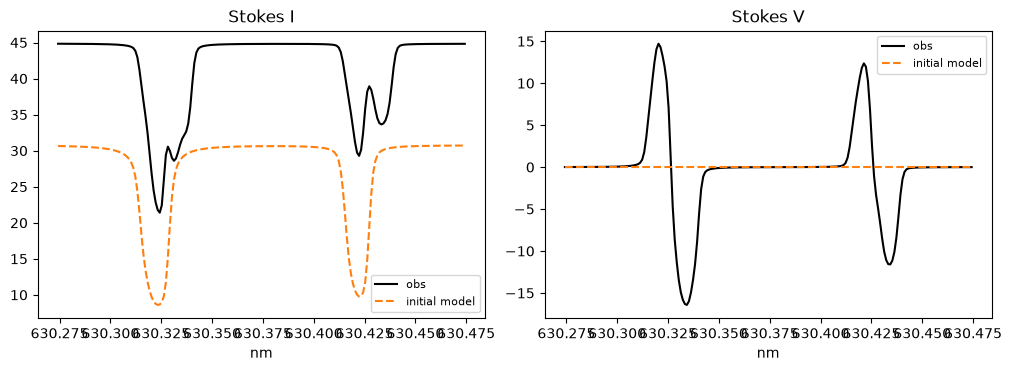

initial misfit  RMS(model-obs)/<Ic>  per Stokes:
  I: 1.978e-01
  Q: 1.225e-03
  U: 1.159e-03
  V: 9.288e-03


In [7]:
nz = 56; dz_m = np.full(nz, 20.0e3)
params = af.load_params('/dat/milic/adora_pinn_develop/pretrained_field.npz')
coords = af.grid_coords(128, 128, nz)
t0 = time.time()
Imod = np.asarray(rf.synth_field(params, coords, (128,128,nz), waves, dz_m, batch=4096))
print(f'initial-model synth {Imod.shape} in {time.time()-t0:.0f}s')
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6), layout='constrained')
ax[0].plot(waves, obs[iV[0],iV[1],0], 'k-', label='obs'); ax[0].plot(waves, Imod[iV[0],iV[1],0], 'C1--', label='initial model')
ax[0].set(title='Stokes I', xlabel='nm'); ax[0].legend(fontsize=8)
ax[1].plot(waves, obs[iV[0],iV[1],3], 'k-', label='obs'); ax[1].plot(waves, Imod[iV[0],iV[1],3], 'C1--', label='initial model')
ax[1].set(title='Stokes V', xlabel='nm'); ax[1].legend(fontsize=8)
plt.show()
mc = float(Ic.mean())
print('initial misfit  RMS(model-obs)/<Ic>  per Stokes:')
for k, s in enumerate('IQUV'):
    print(f'  {s}: {np.sqrt(np.mean((Imod[:,:,k]-obs[:,:,k])**2))/mc:.3e}')

### Summary
The mock testset (128x128, 48 km) is the set of Stokes observations the PINN will invert, on the same
wavelength grid and intensity scale as the forward model. The initial FAL-C model already has a large
misfit - especially Stokes V (model is non-magnetic) - which is the signal the losses in step 6 will
drive down. Saved to `/dat/milic/adora_pinn_develop/inversion_testset.npz`.